# Monstrous Moonshine : l'invariant $j$ et le monstre

**Série Langlands, notebook 2** — à la suite de 01 — Formes modulaires : de $SL_2(\mathbb{Z})$ aux opérateurs de Hecke (notebook 01 de la série, PR #17972).

En 1978, John McKay remarque une coïncidence obscène :

$$196\,884 = 196\,883 + 1$$

Le membre de gauche est le **coefficient de $q$ dans l'invariant modulaire $j$** ; le membre de droite est la **dimension de la plus petite représentation non triviale du groupe monstre $M$** (à un $1$ près — la représentation triviale). Conway et Norton formalisent en 1979 la « Moonshine conjecture » : chaque coefficient de $j$ se décompose en dimensions de représentations irréductibles de $M$, et plus généralement les séries de Thompson associées à chaque élément du groupe sont des fonctions modulaires de genre zéro. Richard Borcherds la prouve en 1992 (médaille Fields 1998) via les algèbres vertex — la même structure qui décrit les cordes bosoniques.

Ce notebook **calcule** tout cela : séries d'Eisenstein, discriminant $\Delta$, coefficients de $j$, décompositions de McKay vérifiées par recherche exacte et dessinées en anatomie, croissance asymptotique de Rademacher, valeurs spéciales $j(i) = 1728$ et le nombre quasi entier de Heegner $163$ — en resserrant au passage le récit de la chasse au monstre (§3). Trois exercices jalonnent le parcours.

## 1. Séries d'Eisenstein

Pour $k \geq 4$ pair, la série d'Eisenstein

$$E_k(\tau) = 1 - \frac{2k}{B_k} \sum_{n \geq 1} \sigma_{k-1}(n)\, q^n, \qquad q = e^{2i\pi\tau}, \qquad \sigma_{k-1}(n) = \sum_{d \mid n} d^{k-1}$$

est une forme modulaire de poids $k$ pour $SL_2(\mathbb{Z})$. Deux d'entre elles engendrent toute l'algèbre : $E_4$ et $E_6$.

In [1]:
def sigma(n, k):
    # Somme des puissances k-iemes des diviseurs de n.
    return sum(d ** k for d in range(1, n + 1) if n % d == 0)

M = 20  # ordre de troncature des q-expansions

def serie_eisenstein(k, M):
    # Coefficients [a_0, ..., a_M] de E_k, entiers (2k/B_k = 240 pour k=4, -504 pour k=6).
    c = {4: 240, 6: -504}[k]
    return [1] + [c * sigma(n, k - 1) for n in range(1, M + 1)]

E4 = serie_eisenstein(4, M)
E6 = serie_eisenstein(6, M)
print("E4 =", E4[:8], "...")
print("E6 =", E6[:8], "...")
assert E4[:5] == [1, 240, 2160, 6720, 17520]
assert E6[:5] == [1, -504, -16632, -122976, -532728]
print("Identites de reference (240*sigma_3, -504*sigma_5) : verifiees.")

E4 = [1, 240, 2160, 6720, 17520, 30240, 60480, 82560] ...
E6 = [1, -504, -16632, -122976, -532728, -1575504, -4058208, -8471232] ...
Identites de reference (240*sigma_3, -504*sigma_5) : verifiees.


Les premiers termes se lisent directement : $\sigma_3(1)=1 \to 240$, $\sigma_3(2)=1+8=9 \to 2160$, $\sigma_5(2) = 1+32 = 33 \to -504 \times 33 = -16\,632$.

## 2. Le discriminant et l'invariant $j$

L'anneau des formes modulaires pour $SL_2(\mathbb{Z})$ est $\mathbb{C}[E_4, E_6]$. La forme

$$\Delta = \frac{E_4^3 - E_6^2}{1728} = q \prod_{n \geq 1} (1 - q^n)^{24}$$

de poids 12 s'annule à l'infini sans s'annuler dans le demi-plan (c'est le $\Delta$ du notebook 01, dont les coefficients sont les $\tau(n)$ de Ramanujan). L'**invariant modulaire**

$$j = \frac{E_4^3}{\Delta} = q^{-1} + 744 + 196\,884\, q + 21\,493\,760\, q^2 + \cdots$$

est une *fonction* modulaire de poids 0, à coefficients entiers — et elle classe les courbes elliptiques complexes à isomorphisme près.

In [2]:
def produit(a, b, M):
    # Produit de deux series tronquees (indices 0..M).
    out = [0] * (M + 1)
    for i in range(M + 1):
        for k in range(i + 1):
            out[i] += a[k] * b[i - k]
    return out

def puissance(a, e, M):
    r = [1] + [0] * M
    for _ in range(e):
        r = produit(r, a, M)
    return r

def inverse_unitaire(D, M):
    # Inverse d'une serie D a constante 1 : coefficients entiers, recursif.
    inv = [0] * (M + 1)
    inv[0] = 1
    for n in range(1, M + 1):
        inv[n] = -sum(D[k] * inv[n - k] for k in range(1, n + 1))
    return inv

E4_3 = puissance(E4, 3, M)
E6_2 = puissance(E6, 2, M)
Delta = [(E4_3[i] - E6_2[i]) // 1728 for i in range(M + 1)]  # = q * D avec D(0) = 1
D = Delta[1:] + [0]
E4_3_sur_D = produit(E4_3, inverse_unitaire(D, M - 1), M - 1)

print("Delta =", Delta[:8], "...  (coefficients tau de Ramanujan)")
print("tau(1..6) attendu : 1, -24, 252, -1472, 4830, -6048")
print()
print("E4^3/D = 1 + 744 q + 196884 q^2 + 21493760 q^3 + ... d'ou j = q^-1 + 744 + ...")
for i, a in enumerate(E4_3_sur_D[:7]):
    print(f"  coeff q^{i} de E4^3/D = {a:>15,}".replace(",", " "))
c = E4_3_sur_D[2:]  # c_1, c_2, ... : coefficients de J = j - 744
assert c[0] == 196884 and c[1] == 21493760 and c[2] == 864299970 and c[3] == 20245856256
print()
print("c_1..c_4 (coefficients de J = j - 744) verifies contre la litterature (Sloane A000521).")

Delta = [0, 1, -24, 252, -1472, 4830, -6048, -16744] ...  (coefficients tau de Ramanujan)
tau(1..6) attendu : 1, -24, 252, -1472, 4830, -6048

E4^3/D = 1 + 744 q + 196884 q^2 + 21493760 q^3 + ... d'ou j = q^-1 + 744 + ...
  coeff q^0 de E4^3/D =               1
  coeff q^1 de E4^3/D =             744
  coeff q^2 de E4^3/D =         196 884
  coeff q^3 de E4^3/D =      21 493 760
  coeff q^4 de E4^3/D =     864 299 970
  coeff q^5 de E4^3/D =  20 245 856 256
  coeff q^6 de E4^3/D = 333 202 640 600

c_1..c_4 (coefficients de J = j - 744) verifies contre la litterature (Sloane A000521).


La structure $q^{-1} + 744 + c_1 q + c_2 q^2 + \cdots$ dit que $j$ a un pôle simple à l'infini — c'est le **générateur du corps des fonctions modulaires** pour $SL_2(\mathbb{Z})$ : toute fonction modulaire de poids nul est une fraction rationnelle en $j$. Le $744$ n'est qu'une convention de normalisation (certaines sources notent $J = j - 744$).

## 3. L'observation de McKay, vérifiée

Le **groupe monstre** $M$ est le plus grand groupe simple sporadique : ordre

$$|M| = 2^{46} \cdot 3^{20} \cdot 5^9 \cdot 7^6 \cdot 11^2 \cdot 13^3 \cdot 17 \cdot 19 \cdot 23 \cdot 29 \cdot 31 \cdot 41 \cdot 47 \cdot 59 \cdot 71 \approx 8 \times 10^{53},$$

construit par Griess en 1982. Ses représentations irréductibles ont des dimensions gigantesques ; les quatre plus petites sont connues de l'ATLAS :

$$1, \quad 196\,883, \quad 21\,296\,876, \quad 842\,609\,326.$$

L'observation de McKay dit que $c_1 = 196\,884$ est la *trace de l'identité sur un espace de dimension* $196\,883 + 1$ — une représentation du monstre plus la triviale. Vérifions que $c_2$ et $c_3$ aussi se décomposent.

In [3]:
dims_atlas = [842609326, 21296876, 196883, 1]  # 4 plus petites irreductibles, ordre decroissant

def decompose_exacte(cible, dims, MU_MAX=2):
    # Cherche des multiplicites 0 <= mu_i <= MU_MAX avec sum(mu_i * d_i) == cible.
    # Retourne {dim: multiplicite} ou None. Backtrack sur dims decroissantes.
    # MU_MAX = 2 encode le fait moonshine : les multiplicites de la serie de
    # l'identite sont petites (sans plafond, la dimension 1 absorberait tout).
    if cible == 0:
        return {}
    if not dims:
        return None
    d, reste = dims[0], dims[1:]
    for mu in range(min(cible // d, MU_MAX), -1, -1):
        sous = decompose_exacte(cible - mu * d, reste)
        if sous is not None:
            return {**sous, d: mu} if mu > 0 else sous
    return None

for n, cn in [(1, c[0]), (2, c[1]), (3, c[2])]:
    dec = decompose_exacte(cn, dims_atlas)
    detail = " + ".join(f"{mu} x {d:,}".replace(",", " ") for d, mu in sorted(dec.items(), reverse=True))
    print(f"c_{n} = {cn:,}".replace(",", " "), " = ", detail)

dec4 = decompose_exacte(c[3], dims_atlas)
print()
print("c_4 =", f"{c[3]:,}".replace(",", " "), "decomposable sur les 4 premieres (mu <= 2) :", dec4 is not None)

c_1 = 196 884  =  1 x 196 883 + 1 x 1
c_2 = 21 493 760  =  1 x 21 296 876 + 1 x 196 883 + 1 x 1
c_3 = 864 299 970  =  1 x 842 609 326 + 1 x 21 296 876 + 2 x 196 883 + 2 x 1

c_4 = 20 245 856 256 decomposable sur les 4 premieres (mu <= 2) : False


**Lecture.** Les trois premiers coefficients de $j$ sont exactement des combinaisons à coefficients *positifs* des dimensions irréductibles du monstre :

- $c_1 = 196\,883 + 1$
- $c_2 = 21\,296\,876 + 196\,883 + 1$
- $c_3 = 842\,609\,326 + 21\,296\,876 + 2 \times 196\,883 + 2 \times 1$

Mais $c_4$ **résiste** : sous le plafond naturel des petites multiplicités, il ne se décompose pas sur les quatre premières dimensions — il faut faire entrer la cinquième représentation irréductible (non fournie ici). Le motif est général : Conway et Norton conjecturent en 1979 que $J(q) = \sum c_n q^n$ est la *série de graded trace de l'identité* sur une structure graduée infinie $V = \bigoplus V_n$ dont chaque $V_n$ est une représentation de $M$ avec $\dim V_1 = 196\,884$ — et que pour *chaque* élément $g \in M$, la série $T_g(q) = \sum \mathrm{tr}(g \mid V_n)\, q^{n-1}$ est une fonction modulaire de **genre zéro** pour un certain groupe $\Gamma_g$. La structure graduée — l'algèbre vertex $V^\natural$, construite par **Frenkel, Lepowsky et Meurman** en 1988 — est l'espace où vit cette conjecture ; **Borcherds** prouve la modularité (donc la conjecture de Conway–Norton) en 1992.

Moonshine relie ainsi trois mondes sans contact apparent : **formes modulaires** (analyse), **groupes finis** (algèbre) et **algèbres vertex** (physique théorique).

### Le récit — une chasse au Snark mathématique

L'histoire vaut le détour, et Margaret Wertheim la raconte dans *Cabinet Magazine* sous le titre « Hunting a Mathematical Snark » — le monstre comme créature de Lewis Carroll, trop improbable pour être rencontrée deux fois. Quelques étapes, d'après ce récit :

- **L'ère des monstres jumeaux.** Bernd Fischer découvre en théorie des groupes une symétrie miroir géante qu'il baptise $M_{22}$, et spécule l'existence de deux cousins plus vastes. John Conway les surnomme les monstres *Baby*, *Middle* et *Super* — le *Middle* s'avérera une chimère, mais le Baby et le Super existent bel et bien.
- **« On ne le verra jamais. »** En 1978, Conway spécule publiquement qu'il ne vivra pas assez pour voir l'existence du monstre vérifiée : Fischer estime qu'une seule des multiplications matricielles nécessaires exigerait **six mois** de calcul.
- **14 janvier 1980.** Robert Griess annonce, sorti de nulle part, avoir **construit le monstre à la main** — par une voie plus terrestre que la méthode des miroirs de Fischer, que Conway et d'autres confirment ensuite par ordinateur. C'est la construction de 1982 citée plus haut.
- **L'espoir de Dyson.** Freeman Dyson confessait son « espoir sournois » (*sneaking hope*) qu'au XXI<sup>e</sup> siècle, les physiciens découvriraient le monstre « intégré de quelque façon insoupçonnée dans la structure de l'univers » — moonshine et théorie des cordes, même intuition.

Le mot *moonshine* lui-même — « clair de lune », avec son parfum d'illusion et de contrebande — dit le scepticisme d'une époque : ces coïncidences numériques semblaient trop belles pour être honnêtes. Jusqu'à ce que Borcherds les change en théorèmes.

La décomposition se **voit** : chaque coefficient $c_n$ empile des étages dont les hauteurs sont les dimensions des représentations irréductibles du monstre. L'échelle est logarithmique — les étages couvrent huit ordres de grandeur, de $1$ à $842\,609\,326$ — et la barre noire marque le total $c_n$ : la somme des étages le retrouve exactement, sans reste.

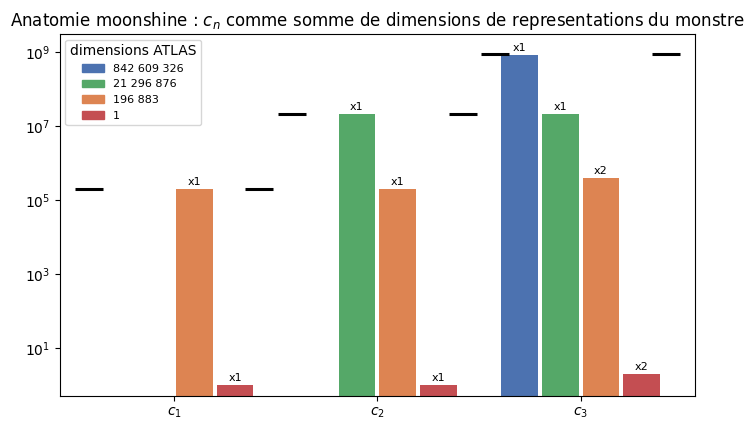

Chaque barre noire (total c_n) est exactement la somme des etages colores : la
representation dominante grandit (196 883 -> 21 296 876 -> 842 609 326), les petites
restent comme couches fines -- la structure fine des multiplicites est le vrai signal.


In [4]:
import matplotlib.pyplot as plt
# Anatomie moonshine : chaque c_n comme somme de dimensions ATLAS (echelle log)
etiquettes = {1: "1", 196883: "196 883", 21296876: "21 296 876", 842609326: "842 609 326"}
couleurs = {1: "#C44E52", 196883: "#DD8452", 21296876: "#55A868", 842609326: "#4C72B0"}
slots = {842609326: -0.30, 21296876: -0.10, 196883: 0.10, 1: 0.30}

fig, ax = plt.subplots(figsize=(7.0, 4.4))
for n in (1, 2, 3):
    dec = decompose_exacte(c[n - 1], dims_atlas)
    for d, mu in sorted(dec.items()):
        if mu:
            ax.bar(n + slots[d], mu * d, width=0.18, color=couleurs[d], align="center")
            ax.text(n + slots[d], mu * d * 1.25, f"x{mu}", ha="center", fontsize=8)
    ax.plot([n - 0.42, n + 0.42], [c[n - 1], c[n - 1]], "k_", ms=20, mew=2.2)

from matplotlib.patches import Patch
handles = [Patch(color=couleurs[d], label=etiquettes[d]) for d in (842609326, 21296876, 196883, 1)]
ax.legend(handles=handles, fontsize=8, title="dimensions ATLAS", loc="upper left")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["$c_1$", "$c_2$", "$c_3$"])
ax.set_yscale("log")
ax.set_ylim(0.5, 3e9)
ax.set_title("Anatomie moonshine : $c_n$ comme somme de dimensions de representations du monstre")
plt.tight_layout()
plt.show()
print("Chaque barre noire (total c_n) est exactement la somme des etages colores : la")
print("representation dominante grandit (196 883 -> 21 296 876 -> 842 609 326), les petites")
print("restent comme couches fines -- la structure fine des multiplicites est le vrai signal.")

Au-delà de l'anatomie, la taille : les $c_n$ explosent. Rademacher (1938) en donne un équivalent exact, que la figure suivante confronte aux coefficients calculés ci-dessus.

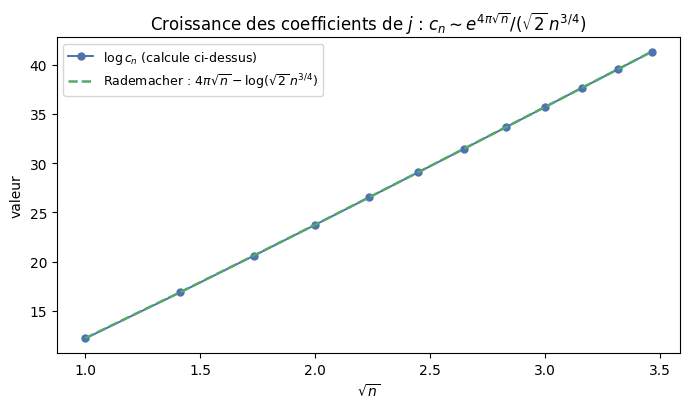

L'ecart entre les deux courbes tend vers une constante : la correction est multiplicative, pas exponentielle.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

ns = np.arange(1, 13)
cn = np.array(c[:12], dtype=float)

fig, ax = plt.subplots(figsize=(7.0, 4.2))
racines = np.sqrt(ns)
ax.plot(racines, np.log(cn), "o-", color="#4C72B0", lw=1.4, ms=5,
        label=r"$\log c_n$ (calcule ci-dessus)")
ax.plot(racines, 4 * np.pi * racines - np.log(np.sqrt(2) * ns ** 0.75), "--", color="#55A868", lw=1.8,
        label=r"Rademacher : $4\pi\sqrt{n} - \log(\sqrt{2}\, n^{3/4})$")
ax.set_xlabel(r"$\sqrt{n}$")
ax.set_ylabel("valeur")
ax.set_title(r"Croissance des coefficients de $j$ : $c_n \sim e^{4\pi\sqrt{n}} / (\sqrt{2}\, n^{3/4})$")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()
print("L'ecart entre les deux courbes tend vers une constante : la correction est multiplicative, pas exponentielle.")

La croissance $e^{4\pi\sqrt{n}}$ est **sous-exponentielle** ($\log c_n / n \to 0$) mais bien plus rapide que tout polynôme — et c'est précisément la **signature du pôle** que $j$ porte à l'infini ($q = 0$). L'opposition est structurelle : les coefficients $\tau(n)$ de $\Delta$ — forme **cuspidale**, nulle à l'infini, sans pôle — croissent au contraire **polynomialement**, $\tau(n) = O(n^{11/2+\varepsilon})$ (conjecture de Ramanujan, prouvée par Deligne en 1974). Pôle contre cuspe : même groupe, même demi-plan, deux croissances qui ne se ressemblent pas — et la différence se lit intégralement dans les coefficients.

## 4. Valeurs spéciales : $j(i) = 1728$

Le rapport $E_4^3/\Delta$ vaut $1728$ en $\tau = i$ : c'est précisément la constante de normalisation choisie pour que $j$ prenne des valeurs entières aux points CM. Numériquement, en $\tau = i$, $q = e^{-2\pi} \approx 0{,}00187$ et les q-séries convergent à l'œil nu.

In [6]:
import cmath

def evalue(coeffs, q):
    # Evalue sum(a_n q^n) pour la serie tronquee [a_0, ..., a_M].
    return sum(a * q ** n for n, a in enumerate(coeffs))

tau = 1j
q = cmath.exp(2j * np.pi * tau)
E4_i = evalue(E4, q)
E6_i = evalue(E6, q)
Delta_i = evalue(Delta, q)
j_i = E4_i ** 3 / Delta_i
print(f"E6(i)    = {E6_i.real:+.2e} {E6_i.imag:+.2e}i   (~0 : i est un point fixe de S)")
print(f"j(i)     = {j_i.real:.9f}")
print(f"ecart a 1728 : {abs(j_i - 1728):.2e}")

E6(i)    = -3.36e-16 +0.00e+00i   (~0 : i est un point fixe de S)
j(i)     = 1728.000000000
ecart a 1728 : 9.09e-13


$E_6$ s'annule en $i$ (point fixe de l'involution $S$), si bien que $j(i) = E_4(i)^3/\Delta(i) = 1728 \cdot E_4(i)^3/E_4(i)^3$ — la valeur 1728 est structurale, pas numérique.

## 5. Exercices

Trois exercices, du plus mécanique au plus frappant. Chacun a son stub exécutable sans erreur.

### Exercice 1 — Toutes les décompositions

Écrire `multiplicites(cible, dims)` — même principe que `decompose_exacte`, mais qui retourne **toutes** les solutions (plafond `MU_MAX = 2` conservé). L'appliquer à $c_3$, puis à $c_3 - 842\,609\,326 = 21\,690\,644$ et constater que la décomposition trouvée est l'union de celles de $c_1$ et $c_2$ : c'est la linéarité des traces.

In [7]:
def multiplicites(cible, dims):
    # TODO etudiant : retourner la liste de TOUTES les decompositions
    # {dim: multiplicite} de cible sur dims (multiplicites 0..2).
    # Indice : adapter decompose_exacte pour accumuler les solutions au lieu
    # de s'arreter a la premiere ; rester recursif.
    pass  # TODO etudiant
    return None

# Verification attendue une fois complete :
# sols = multiplicites(c[2], dims_atlas)
# print(len(sols), "solution(s) pour c_3")            # 1
# sols2 = multiplicites(c[2] - 842609326, dims_atlas)
# print(sols2)                                        # {21296876:1, 196883:2, 1:2}
print("Exercice 1 a completer")

Exercice 1 a completer


### Exercice 2 — $j$ via le module $\lambda$

Le module $\lambda(\tau) = \theta_2^4/\theta_3^4$ (une fonction modulaire pour $\Gamma(2)$) déparamètre $j$ :

$$j = 256\,\frac{(1 - \lambda + \lambda^2)^3}{\lambda^2 (1 - \lambda)^2}.$$

Écrire `j_de_lambda(lam)` et vérifier : (a) $\lambda = 1/2$ donne $j = 1728$ (c'est $\lambda(i)$) ; (b) les racines de $\lambda^2 - \lambda + 1$ donnent $j = 0$ — et ce sont les valeurs de $\lambda$ au point $\rho = e^{i\pi/3}$, où $E_4$ s'annule.

In [8]:
def j_de_lambda(lam):
    # TODO etudiant : la formule ci-dessus, en une ligne.
    # Retourner 256 * (1 - lam + lam**2)**3 / (lam**2 * (1 - lam)**2).
    pass  # TODO etudiant
    return None

# Verification attendue :
# print(j_de_lambda(0.5))                # ~1728
# zeta6 = 0.5 + (0.75)**0.5 * 1j        # racine de lam^2 - lam + 1
# print(abs(j_de_lambda(zeta6)))         # ~0
print("Exercice 2 a completer")

Exercice 2 a completer


### Exercice 3 — Le nombre quasi entier de Ramanujan

Pour $\tau = (1 + i\sqrt{163})/2$ (nombre de Heegner $163$, nombre de classes 1), $j(\tau) = (-640\,320)^3$ **exactement** — d'où la coincidence de Ramanujan :

$$e^{\pi\sqrt{163}} \approx 640\,320^3 + 744 = 262\,537\,412\,640\,768\,743{,}9999\ldots$$

Calculer $j(\tau)$ numériquement (attention : $q = -e^{-\pi\sqrt{163}} \approx -3{,}8 \times 10^{-18}$, la sommation naïve exige `mpmath` et une précision $\geq 30$ chiffres) et mesurer $|j(\tau) - (-640320)^3|$.

In [9]:
from mpmath import mp, mpc, exp as mpexp, pi as mppi

def j_heegner(d=163, dps=40):
    # TODO etudiant : construire tau = (1 + i*sqrt(d))/2, q = exp(2i*pi*tau),
    # sommer j ~ 1/q + 744 + c_1 q + c_2 q^2 + c_3 q^3 (les c_n sont dans la
    # liste c ci-dessus), retourner le resultat mpc.
    # Indice : mp.dps = dps ; mpexp ; mpc(0, 1) pour i ; sqrt via **mpf('0.5').
    mp.dps = dps
    pass  # TODO etudiant
    return None

# Verification attendue :
# val = j_heegner()
# cible = -640320 ** 3
# print(abs(val - cible))    # ~1e-25 ou moins
print("Exercice 3 a completer")

Exercice 3 a completer


## Conclusion

Le fil de la série : le notebook 01 a établi le socle ($SL_2(\mathbb{Z})$, formes modulaires, opérateurs de Hecke, $\Delta$ et $\tau$) ; celui-ci montre que la fonction qui **coiffe** cette théorie — l'invariant $j$ — porte dans ses coefficients l'ombre du plus grand groupe simple sporadique. C'est la face « surprises numériques » du programme de Langlands évoqué par Serre : face orthogonale à la montée générale grothendieckienne, mais même famille d'objets — formes modulaires, fonctions $L$, symétries cachées.

Pour poursuivre dans le dépôt :

- 01 — Formes modulaires : de $SL_2(\mathbb{Z})$ aux opérateurs de Hecke (notebook 01, PR #17972) — le socle calculatoire ;
- [Lean-16a — Conway: Man and Work](../Lean-16a-Conway-Man-and-Work.ipynb) — le contexte biographique (Conway a co-signé la conjecture et nommé « moonshine ») ;
- [Serre100 — 07 : zéros de fonctions $L$, gaps GUE](../Serre100/07-zeros-fonctions-l-gaps-gue.ipynb) — la face analytique ;
- [App-32 : Szpiro–Pasten 2026](../../../Search/Applications/Search/App-32-Szpiro-Pasten-2026.ipynb) — une correspondance de Jacquet–Langlands qui contraint un invariant calculable.

**Sources** : Conway & Norton, *Monstrous Moonshine*, Bull. LMS **11** (1979) ; Borcherds, *Monstrous moonshine and monstrous Lie superalgebras*, Invent. Math. **109** (1992) ; Frenkel, Lepowsky & Meurman, *Vertex Operator Algebras and the Monster*, Academic Press (1988) ; Diamond & Shurman, *A First Course in Modular Forms* (ch. 1) ; Serre, *A Course in Arithmetic* (ch. VII). Récit : Margaret Wertheim, « Hunting a Mathematical Snark: The sublime symmetry of the Monster », *Cabinet Magazine* n° 34 (2009), [cabinetmagazine.org/issues/34/wertheim.php](https://www.cabinetmagazine.org/issues/34/wertheim.php).